In [558]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("results_models.csv", sep='\t')
df.columns = ['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1']

df2 = pd.read_csv("results_models.csv", sep='\t')
df2.columns = ['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1']

# Concatenate the dataframes
df = pd.concat([df, df2], ignore_index=True)



In [559]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

In [560]:
len(df)


1030

In [561]:
len(df)


1030

In [562]:
df.columns


Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

In [563]:

df['FC Dropout']

0       0.4
1       0.4
2       0.4
3       0.4
4       0.4
       ... 
1025    0.4
1026      -
1027      -
1028      -
1029    0.6
Name: FC Dropout, Length: 1030, dtype: object

In [564]:

# #df = df[df['Model'] == 'stacked']
# #df['No. Layers'] = df['No. Layers'].apply(lambda x: 0 if x == '-' else x)

# df['FC Dropout'] = df['FC Dropout'].apply(float)
# df['Trasnf. Dropout'] = df['Trasnf. Dropout'].apply(float)

In [565]:
len(df)


1030

In [566]:
# df = df[df['FC Dropout'] > 0.3]
# df = df[df['Trasnf. Dropout'] > 0.3]

In [567]:
df['FC Dropout'].unique()

array(['0.4', '0.6', '0.8', '-'], dtype=object)

In [568]:
len(df)


1030

In [569]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

In [570]:
df = df.drop_duplicates()


In [571]:
df = df.sort_values(by=['Dataset', 'Model', 'LM', 'Language', 'No. Layers', 'Attention Type'])


In [572]:
len(df)


475

In [573]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

In [574]:
df.to_csv('results.csv', sep='\t', index=False)


/Users/eboros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


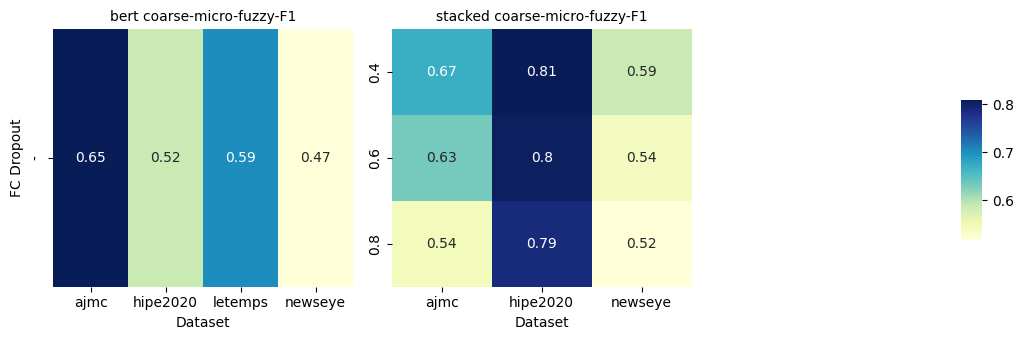

In [576]:
# Aggregate by the three columns of interest
df_agg = df.groupby(['Model', 'FC Dropout', 'Dataset']).agg({'coarse-micro-fuzzy-F1': 'mean'}).reset_index()

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g = sns.FacetGrid(df_agg, col="Model", col_wrap=3, height=3.5, sharex=False, sharey=False)
cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Positioning the colorbar
g = g.map_dataframe(draw_heatmap, 
                    'Dataset', 
                    'FC Dropout', 
                    'coarse-micro-fuzzy-F1', 
                    cbar_ax=cbar_ax, 
                    annot=True, 
                    cmap="YlGnBu")

# Fixing the titles of the FacetGrid
g.set_titles(col_template="{col_name} coarse-micro-fuzzy-F1")


In [577]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

/Users/eboros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


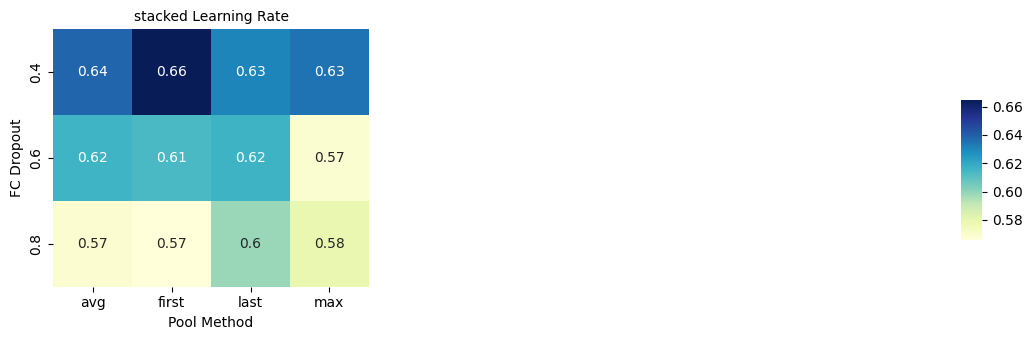

In [525]:
# Aggregate by the three columns of interest
df_agg = df.groupby(['Model', 'Pool Method', 'FC Dropout']).agg({'coarse-micro-fuzzy-F1': 'mean'}).reset_index()

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g = sns.FacetGrid(df_agg, col="Model", col_wrap=3, height=3.5, sharex=False, sharey=False)
cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Positioning the colorbar
g = g.map_dataframe(draw_heatmap, 
                    'Pool Method', 
                    'FC Dropout', 
                    'coarse-micro-fuzzy-F1', 
                    cbar_ax=cbar_ax, 
                    annot=True, 
                    cmap="YlGnBu")

# Fixing the titles of the FacetGrid
g.set_titles(col_template="{col_name} Learning Rate")


/Users/eboros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


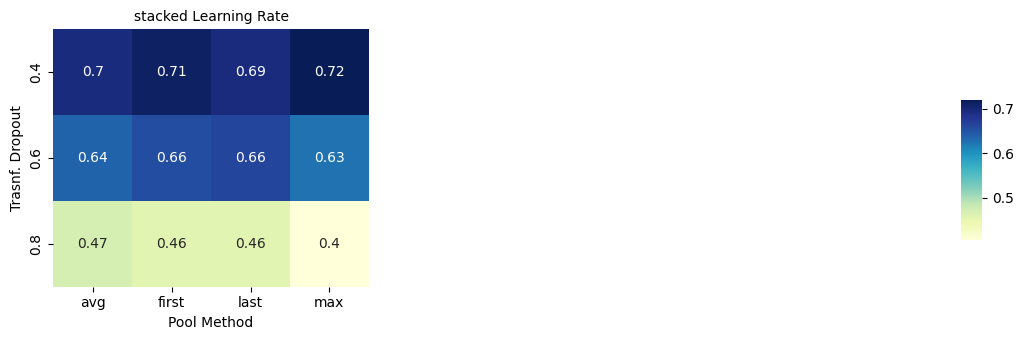

In [526]:
# Aggregate by the three columns of interest
df_agg = df.groupby(['Model', 'Pool Method', 'Trasnf. Dropout']).agg({'coarse-micro-fuzzy-F1': 'mean'}).reset_index()

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g = sns.FacetGrid(df_agg, col="Model", col_wrap=3, height=3.5, sharex=False, sharey=False)
cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Positioning the colorbar
g = g.map_dataframe(draw_heatmap, 
                    'Pool Method', 
                    'Trasnf. Dropout', 
                    'coarse-micro-fuzzy-F1', 
                    cbar_ax=cbar_ax, 
                    annot=True, 
                    cmap="YlGnBu")

# Fixing the titles of the FacetGrid
g.set_titles(col_template="{col_name} Learning Rate")


/Users/eboros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


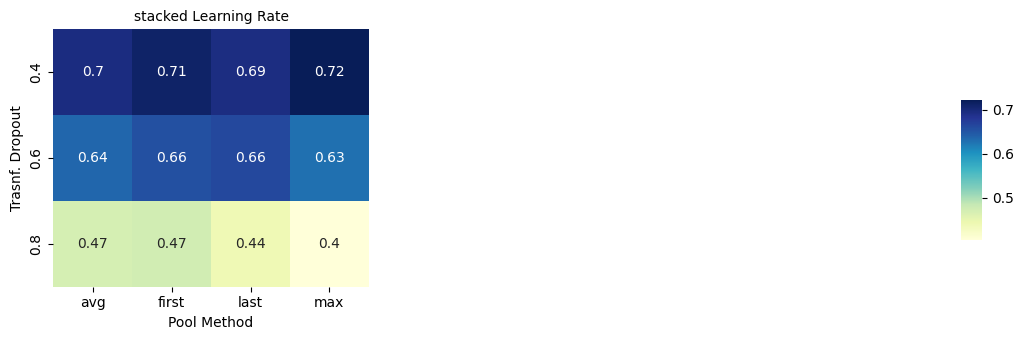

In [487]:
# Aggregate by the three columns of interest
df_agg = df.groupby(['Model', 'Pool Method', 'Trasnf. Dropout']).agg({'coarse-micro-fuzzy-F1': 'mean'}).reset_index()

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs)

g = sns.FacetGrid(df_agg, col="Model", col_wrap=3, height=3.5, sharex=False, sharey=False)
cbar_ax = g.fig.add_axes([.92, .3, .02, .4])  # Positioning the colorbar
g = g.map_dataframe(draw_heatmap, 
                    'Pool Method', 
                    'Trasnf. Dropout', 
                    'coarse-micro-fuzzy-F1', 
                    cbar_ax=cbar_ax, 
                    annot=True, 
                    cmap="YlGnBu")

# Fixing the titles of the FacetGrid
g.set_titles(col_template="{col_name} Learning Rate")


In [488]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

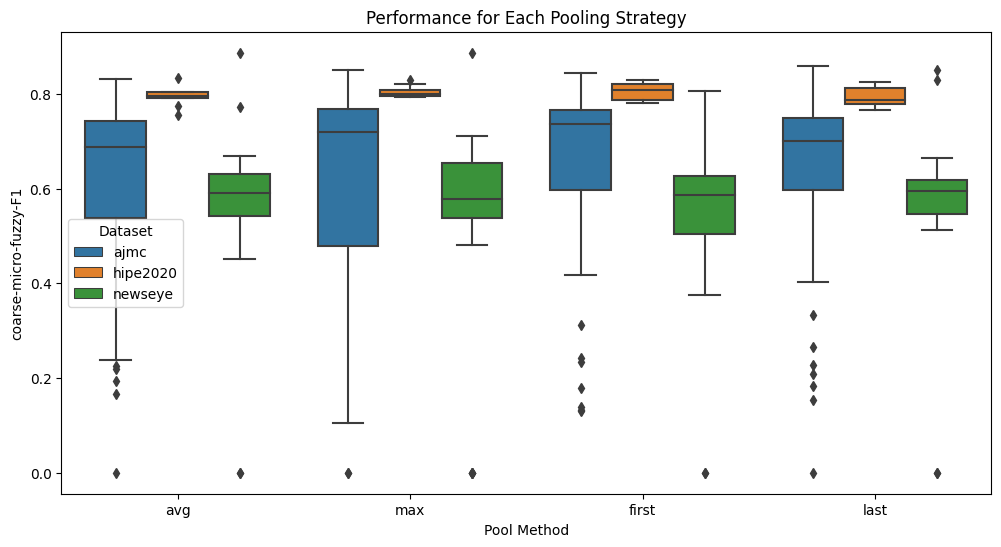

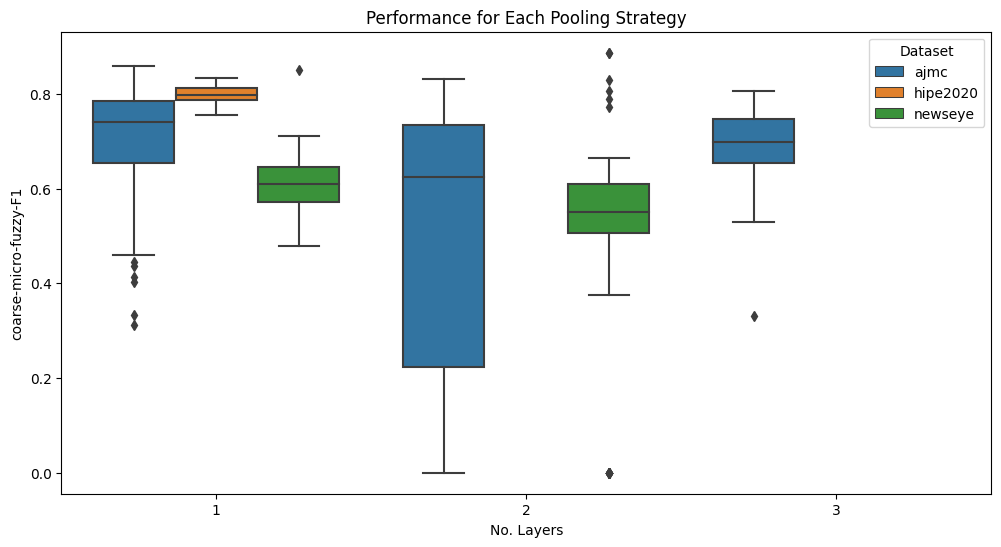

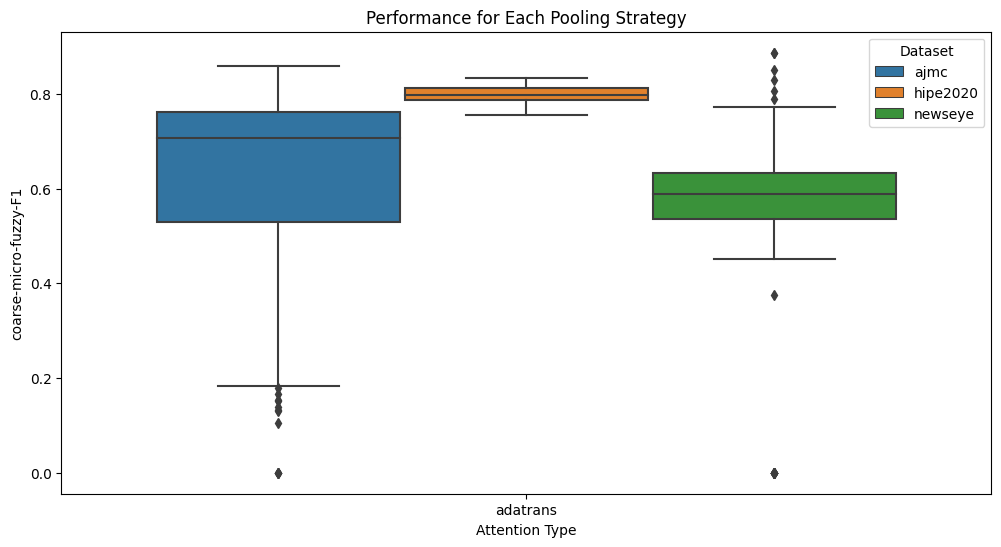

In [530]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is the DataFrame containing your data

# 2. Bar plots for each pooling strategy
plt.figure(figsize=(12, 6))
sns.boxplot(x="Pool Method", y="coarse-micro-fuzzy-F1", hue="Dataset", data=df)
plt.title("Performance for Each Pooling Strategy")
plt.show()

# 3. Bar plots for each No. Layers
plt.figure(figsize=(12, 6))
sns.boxplot(x="No. Layers", y="coarse-micro-fuzzy-F1", hue="Dataset", data=df)
plt.title("Performance for Each Pooling Strategy")
plt.show()

# 4. Bar plots for each Attention Type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Attention Type", y="coarse-micro-fuzzy-F1", hue="Dataset", data=df)
plt.title("Performance for Each Pooling Strategy")
plt.show()



In [490]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

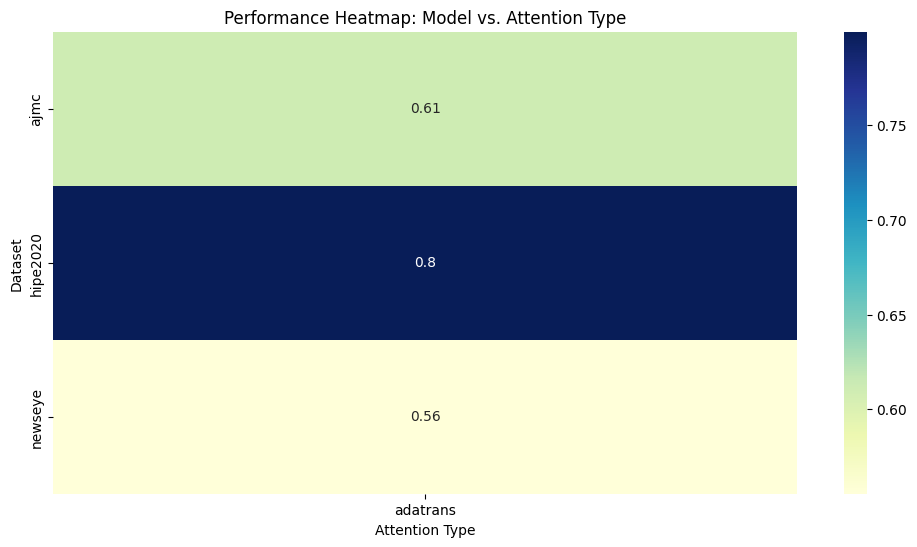

In [533]:
plt.figure(figsize=(12, 6))
pivot_table = df.pivot_table(index="Dataset", columns="Attention Type", values="coarse-micro-fuzzy-F1", aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Performance Heatmap: Model vs. Attention Type")
plt.show()


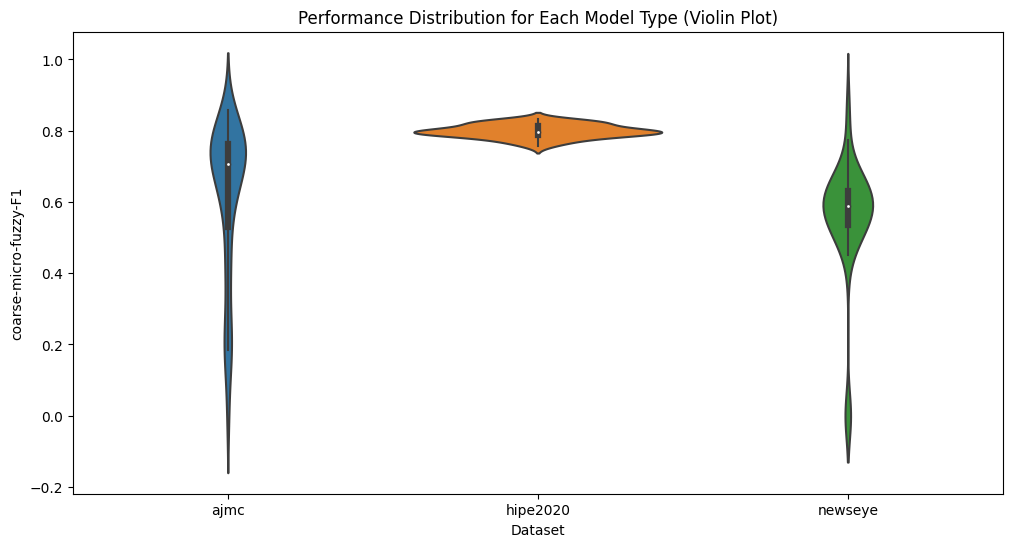

In [534]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="Dataset", y="coarse-micro-fuzzy-F1", data=df)
plt.title("Performance Distribution for Each Model Type (Violin Plot)")
plt.show()


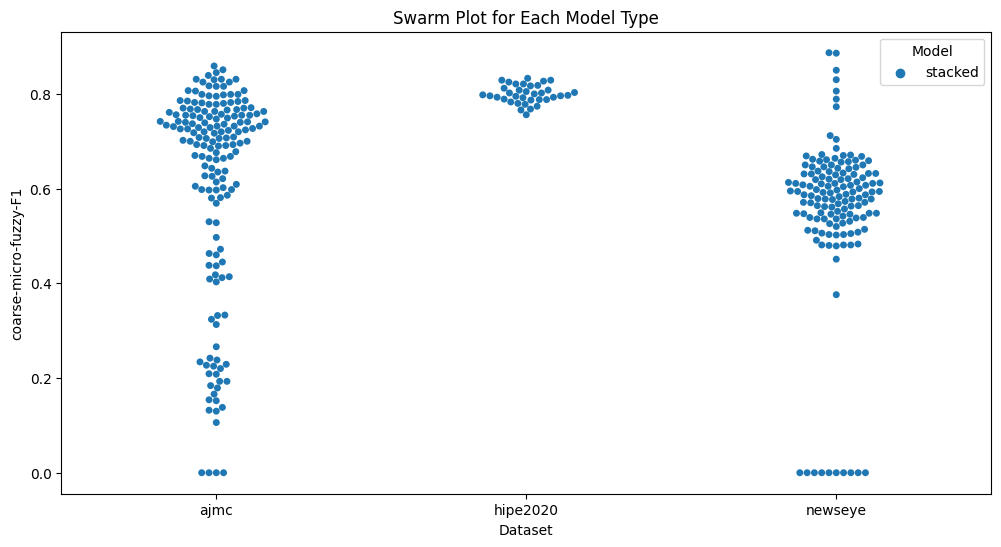

In [535]:
plt.figure(figsize=(12, 6))
sns.swarmplot(x="Dataset", y="coarse-micro-fuzzy-F1", hue='Model', data=df)
plt.title("Swarm Plot for Each Model Type")
plt.show()


In [495]:
df.columns

Index(['Dataset', 'Model', 'Language', 'LM', 'No. Layers', 'Attention Type',
       'No. Heads', 'Head Dimension', 'Positional Encoding', 'Trasnf. Dropout',
       'FC Dropout', 'Pool Method', 'Learning Rate', 'coarse-micro-fuzzy-P',
       'coarse-micro-fuzzy-R', 'coarse-micro-fuzzy-F1',
       'coarse-micro-strict-P', 'coarse-micro-strict-R',
       'coarse-micro-strict-F1', 'fine-micro-fuzzy-P', 'fine-micro-fuzzy-R',
       'fine-micro-fuzzy-F1', 'fine-micro-strict-P', 'fine-micro-strict-R',
       'fine-micro-strict-F1'],
      dtype='object')

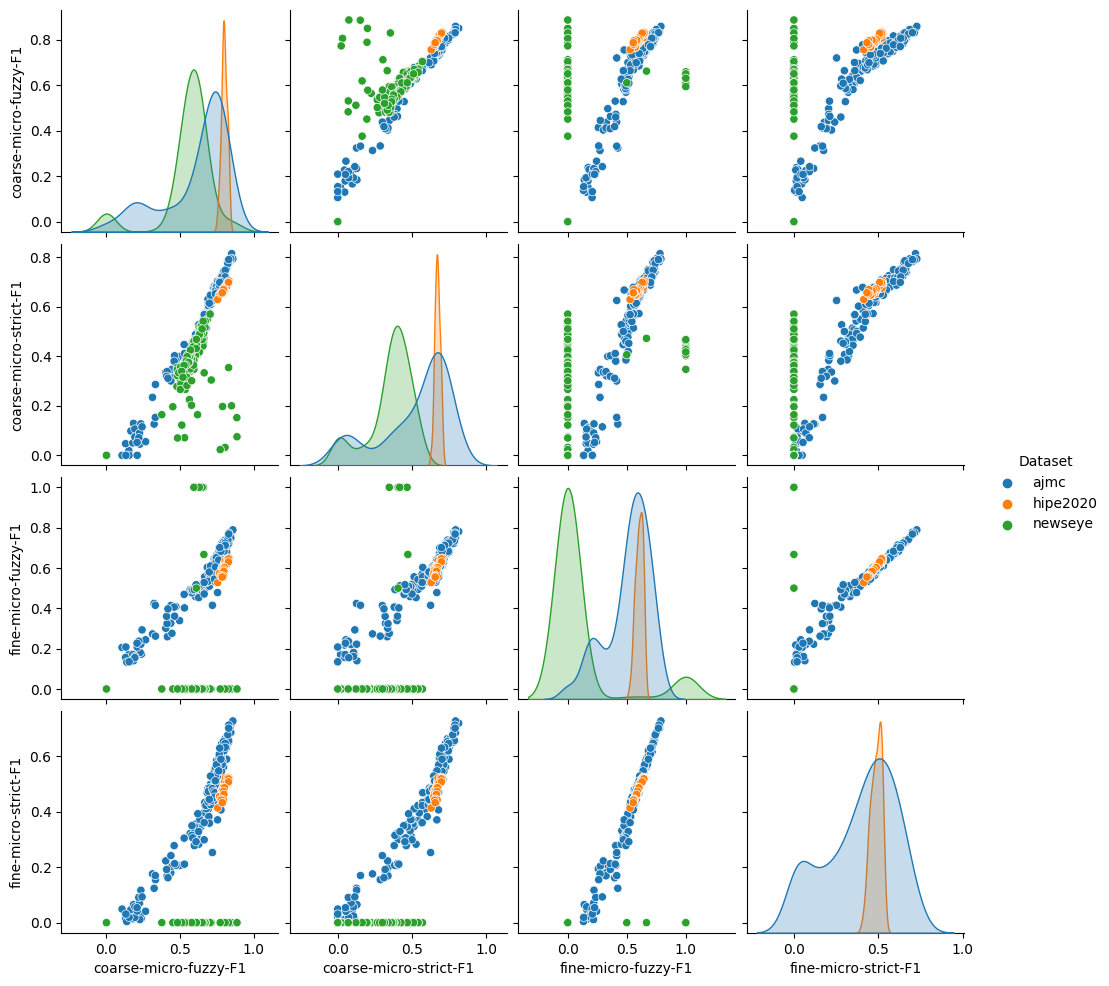

In [536]:
sns.pairplot(df[["coarse-micro-fuzzy-F1", "coarse-micro-strict-F1", "fine-micro-fuzzy-F1", "fine-micro-strict-F1", "Dataset"]], hue="Dataset")
plt.show()


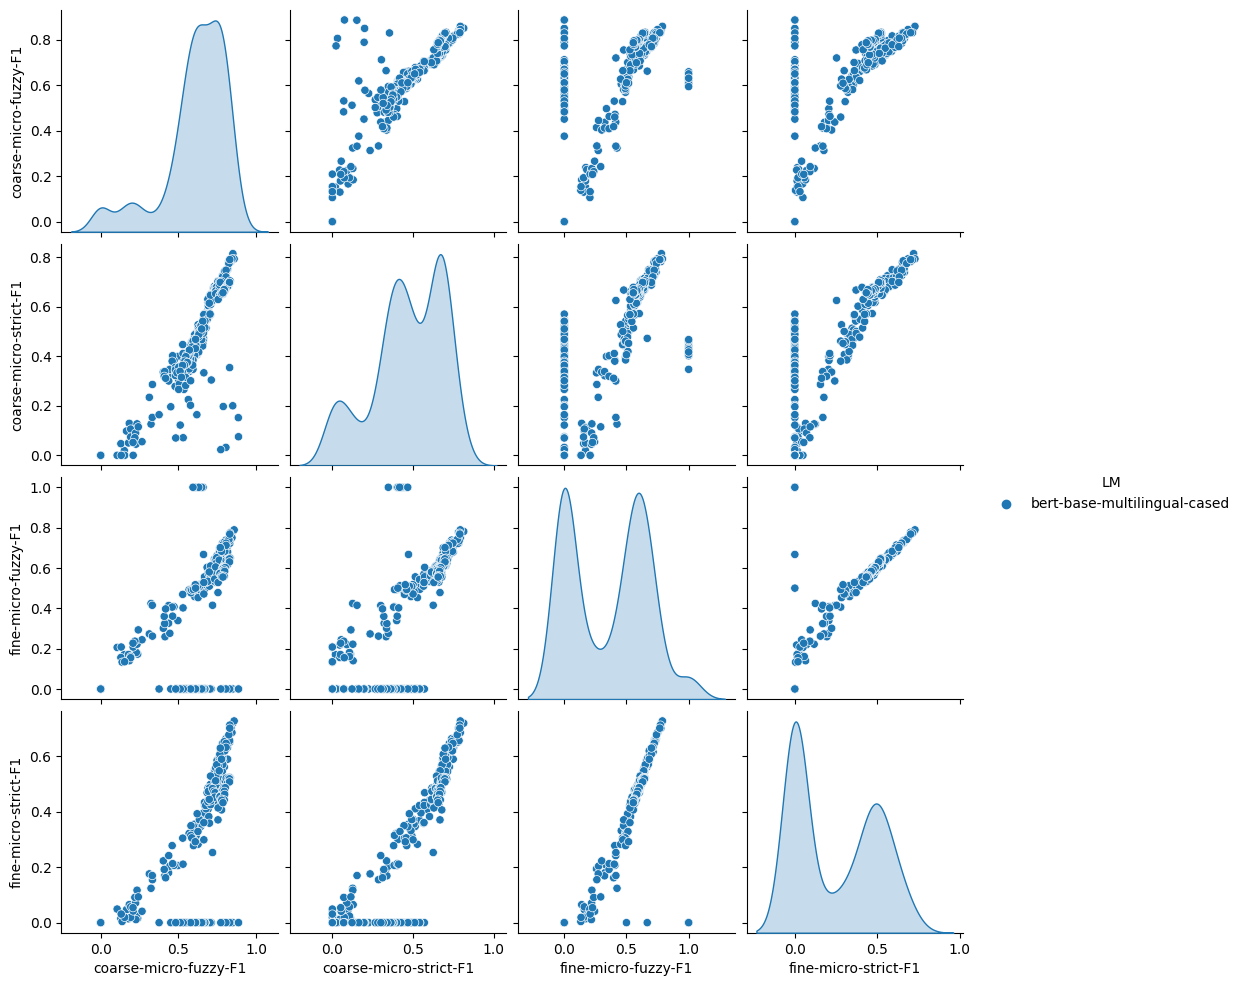

In [537]:
sns.pairplot(df[["coarse-micro-fuzzy-F1", "coarse-micro-strict-F1", "fine-micro-fuzzy-F1", "fine-micro-strict-F1", "LM"]], hue="LM")
plt.show()


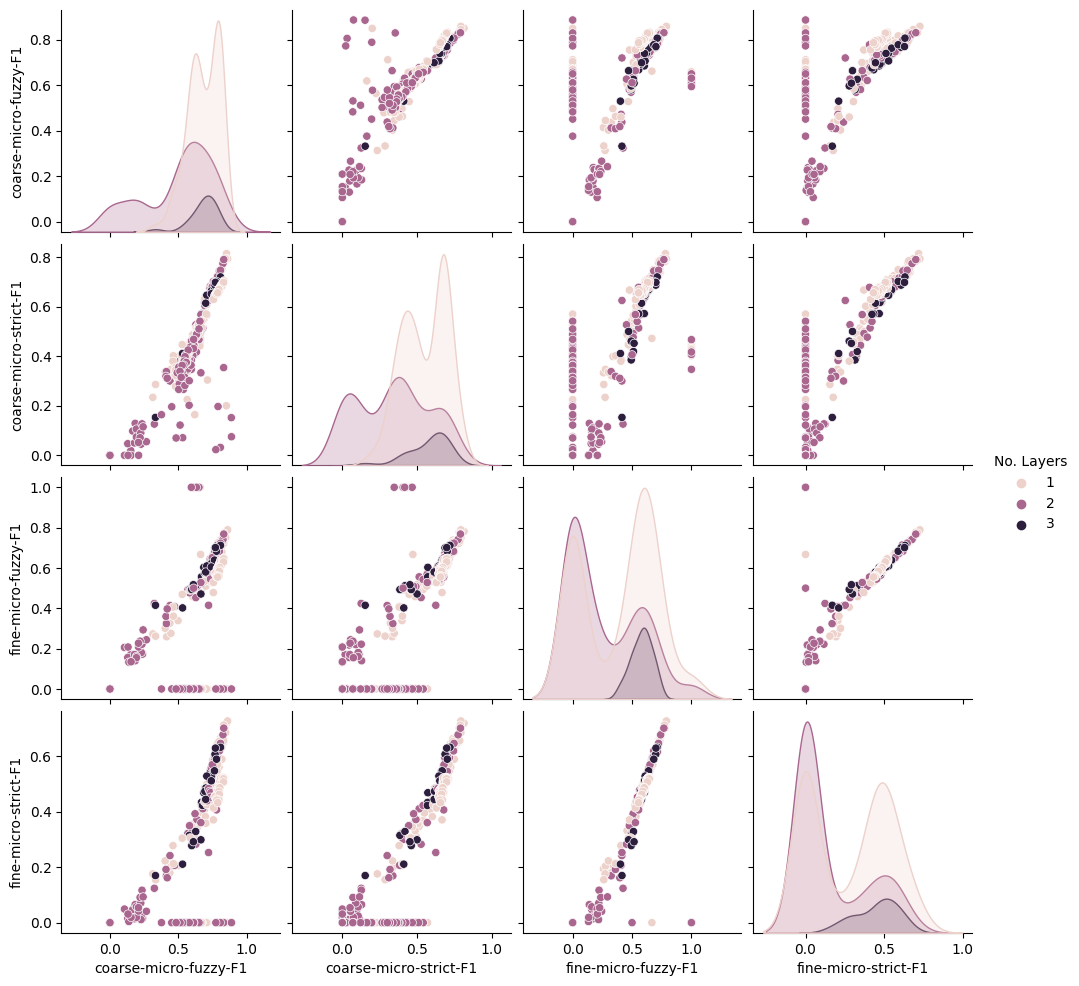

In [538]:
sns.pairplot(df[["coarse-micro-fuzzy-F1", "coarse-micro-strict-F1", "fine-micro-fuzzy-F1", "fine-micro-strict-F1", "No. Layers"]], hue="No. Layers")
plt.show()

In [457]:
df['No. Layers'].unique()

array(['-', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'],
      dtype=object)

In [458]:
df['No. Layers'] = df['No. Layers'].apply(lambda x: 0 if x == '-' else x)


In [459]:
df['No. Layers'] = df['No. Layers'].apply(str)

In [460]:
df = df.sort_values(by="No. Layers")


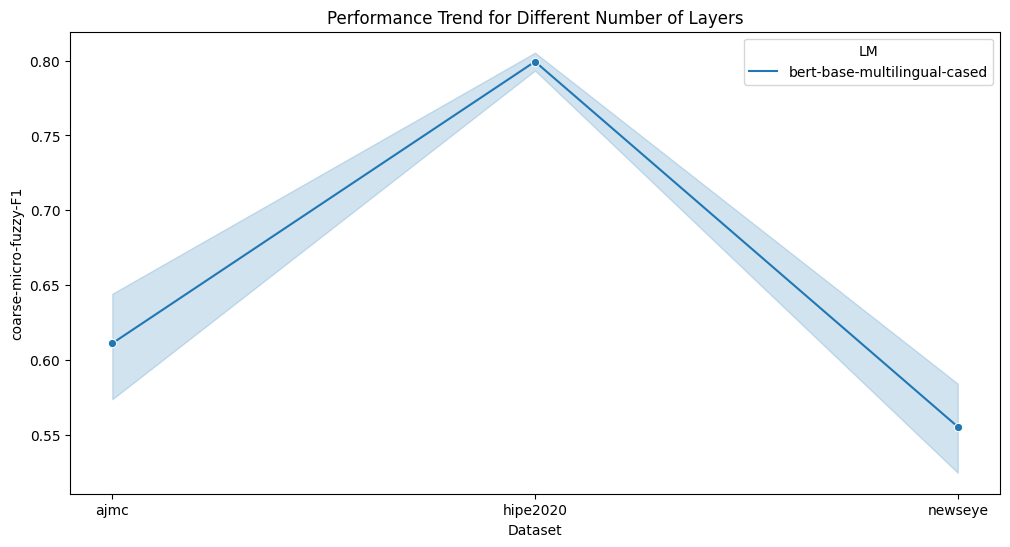

In [539]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="Dataset", y="coarse-micro-fuzzy-F1", hue="LM", data=df, marker="o")
plt.title("Performance Trend for Different Number of Layers")
plt.show()


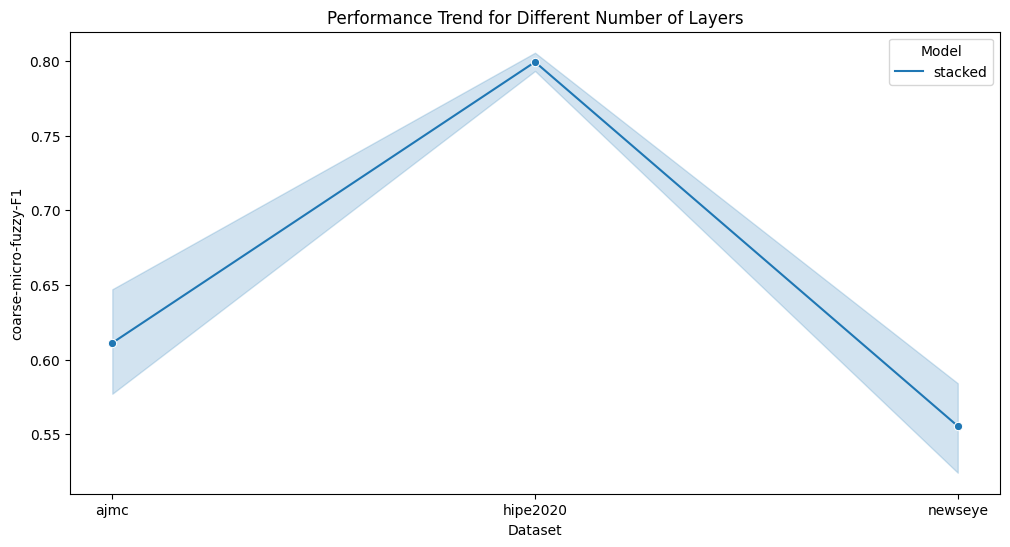

In [540]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="Dataset", y="coarse-micro-fuzzy-F1", hue="Model", data=df, marker="o")
plt.title("Performance Trend for Different Number of Layers")
plt.show()
